In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import ast 

## 1ere section : analyse du dataset (arxiv)

à l'issue de ce notebook nous aurons l'occasion de parcourir ce dataset, de traiter l'étendu des données le constituant (données textuelles précisèment), les transformer et appliquer un problème de ML dessus

le dataset : arXiv paper abstract dataset for building multi-label text classifiers. // https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts/data 


In [62]:
def charger_dataset(chemin_dataset : str = "./data/arxiv_data.csv"):
    #chemin par défaut renvoie au dataset avec abstract 
    return pd.read_csv(chemin_dataset)

df = charger_dataset()
df.describe()

,titles,summaries,terms
count,51774,51774,51774
unique,38972,38979,3157
top,Transformers in Vision: A Survey,Astounding results from Transformer models on ...,['cs.CV']
freq,7,7,17369


### Analyse des données du dataset 

Nombre total de documents : 51774
Colonnes disponibles : ['titles', 'summaries', 'terms']
Valeurs manquantes par colonne :
titles       0
summaries    0
terms        0
dtype: int64
Nombre de catégories uniques : 3157
Distribution des catégories (top 10) :
terms
['cs.CV']                        17369
['cs.LG', 'stat.ML']              5251
['cs.LG']                         2732
['cs.CV', 'cs.LG']                2067
['cs.LG', 'cs.AI']                1702
['cs.LG', 'cs.AI', 'stat.ML']     1470
['stat.ML', 'cs.LG']              1376
['cs.CV', 'cs.AI']                 939
['cs.CV', 'cs.LG', 'eess.IV']      855
['cs.CV', 'eess.IV']               769
Name: count, dtype: int64
nombre réel de catégories unique :  1099  => catégories : 
  {'q-fin.TR', '2010', 'I.2.6; I.4', 'I.5.4; I.2.10', 'I.2.2; I.2.7; I.2.6; I.5.1', '65D18, 68U10', '62G05, 62G08, 60G10, 60J05, 62M05, 62M10', '68T05, 68Q32', '68T05, 68T07', '68T40, 68T45, 68T01', 'cs.DM', 'I.4.9; I.4.9; I.5.0; I.5.4', 'I.2.0; I.2.6', 'G.2;G.1.

Text(0, 0.5, 'Nombre de documents')

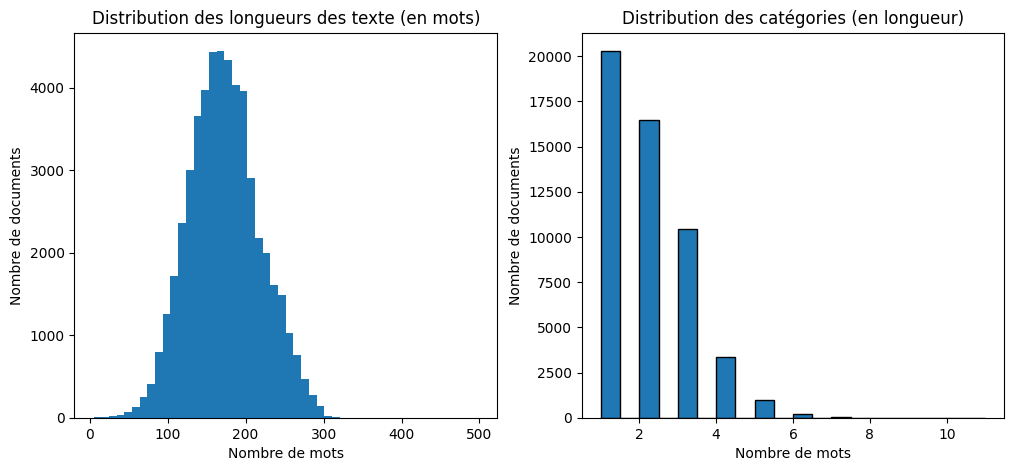

In [63]:
num_documents = df.shape[0]
print(f"Nombre total de documents : {num_documents}")

colonnes = df.columns.tolist()
print(f"Colonnes disponibles : {colonnes}")

valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes)

colonne_categories = 'terms'  
colonnes_texte = 'summaries'  

### Region 1 : analyse des catégories : terms 


num_categories = df[colonne_categories].nunique()
print(f"Nombre de catégories uniques : {num_categories}")

distribution_categories = df[colonne_categories].value_counts()
print("Distribution des catégories (top 10) :")
print(distribution_categories.head(10))



ensemble_categories = set()
for categories_str in df[colonne_categories]:
    #convertir la chaine et liste 
    categories_list = ast.literal_eval(categories_str) 
    ensemble_categories.update(categories_list)
        

print("nombre réel de catégories unique : ",len(ensemble_categories)," => catégories : \n ",ensemble_categories)

df["longueur_categories"] = df[colonne_categories].apply(lambda x : len(ast.literal_eval(x)))
moyenne_labels_par_doc = df["longueur_categories"].mean()
max_labels_par_doc = df["longueur_categories"].max()
print(f"Nombre moyen de labels par document : {moyenne_labels_par_doc}")
print(f"Nombre maximum de labels par document : {max_labels_par_doc}")


## 2 : analyse de la colonne texte  

df["longueur_texte"] = df[colonnes_texte].astype(str).str.split().apply(len)
longueur_moyenne = df["longueur_texte"].mean()
longueur_mediane = df["longueur_texte"].median()
longueur_min = df["longueur_texte"].min()
longueur_max = df["longueur_texte"].max()
print(f"Longueur moyenne des abstracts (mots) : {longueur_moyenne}")
print(f"Longueur médiane des abstracts (mots) : {longueur_mediane}")
print(f"Longueur minimale : {longueur_min}, maximale : {longueur_max}")
 
 
fig, graphiques = plt.subplots(1, 2, figsize=(12, 5))
graphiques[0].hist(df["longueur_texte"], bins=50)
graphiques[0].set_title('Distribution des longueurs des texte (en mots)')
graphiques[0].set_xlabel('Nombre de mots')
graphiques[0].set_ylabel('Nombre de documents')

graphiques[1].hist(df["longueur_categories"], bins=20, edgecolor='black')
graphiques[1].set_title('Distribution des catégories (en longueur)')
graphiques[1].set_xlabel('Nombre de mots')
graphiques[1].set_ylabel('Nombre de documents')


# #présence de doublons .. .suppression au niveau de summaries 
# doublons_summaries = df[df.duplicated(subset=["title","summaries"], keep=False)]
# print("\nExemples de doublons sur summaries (premiers 5) :")
# print(doublons_summaries[["titles", "summaries", "terms"]].head(5))


première analyse à chaud : difficultés quant au nombre de catégories distinctes 1099 => à voir si on en garde que les top-k plus fréquentes ? 

MultiLabelClassification ? avec seuillage sur une sigmoide à la fin (ou garder softmax sur une seule sortie seuleemnt parmi plusieurs labels ???) 

Stratégie : oneVsRest/ All , classe CS et le reste .... et ensuite physique et le reste (y compris CS ...) ??? wrapper autour d'un classifier offert par scikit 
mais on traite pas les similarités entre catégories ??? car nous supposons que les labels sont indépendants, optimisation en ajoutant les prédictions dans les features si jamais ??? à explorer le classifierChain ? 
p(X)=ML , seconde préd P(X+ML)= CV ? 



In [64]:
df = df.drop_duplicates(subset=["titles","summaries"]).reset_index(drop=True)
df.shape

(38985, 5)

### Comptage de classes avant création nouveaux labels

In [65]:
from collections import Counter

def comptage_categories(colonne : str , top_k = 20) : 
    categories_uniques = []
    if colonne == colonne_categories : 
        for categories_str in df[colonne]:
            categories_liste = ast.literal_eval(categories_str)
            categories_uniques.extend(categories_liste)  
    elif colonne == "categories_a_garder":
        for categorie in df[colonne]:
            categories_uniques.extend(categorie) 
    else : #elt unique
        categories_uniques = df[colonne]
    categories_compteurs = Counter(categories_uniques)

    top_k_categories = categories_compteurs.most_common(top_k)

    set_temporaire = set()
    print(f"Top {top_k} catégories (par fréquence) :")
    for categorie , count in top_k_categories:
        print(f"{categorie} ==> : {count}")
        set_temporaire.add(categorie)
    return list(set_temporaire)
        
        

liste_topk = comptage_categories(colonne_categories)

print(liste_topk)


Top 20 catégories (par fréquence) :
cs.CV ==> : 22262
cs.LG ==> : 22247
stat.ML ==> : 12429
cs.AI ==> : 5951
eess.IV ==> : 1763
cs.RO ==> : 1493
cs.CL ==> : 1096
cs.NE ==> : 1014
cs.CR ==> : 590
math.OC ==> : 583
eess.SP ==> : 481
cs.GR ==> : 446
cs.SI ==> : 430
cs.SY ==> : 387
cs.MM ==> : 385
cs.IR ==> : 351
cs.MA ==> : 304
eess.SY ==> : 297
cs.HC ==> : 279
cs.IT ==> : 242
['eess.IV', 'stat.ML', 'cs.NE', 'cs.GR', 'cs.SY', 'cs.AI', 'cs.CV', 'cs.IR', 'cs.HC', 'cs.LG', 'cs.CL', 'cs.MA', 'cs.RO', 'cs.SI', 'eess.SY', 'math.OC', 'cs.IT', 'eess.SP', 'cs.MM', 'cs.CR']


cv : computer vison and pattern recognition 

lg : machihne learning aspects 

stats.ml : orientation statistique 

ai :systèmes experts , ia symbolique 

eess.iv : image video processing

ro : robotics 

cl : computation and language

ne : neural and evolutionary computing

cr : cryptography and security

sp : signal processing

gr : graphics

IR : information retrieval


In [66]:
## Création nouveaux labels 
"""idée : garder premier élement de la liste pour l'instant"""
def get_premier_element_liste_categorie(liste_str : str) -> str : 
    liste_converti = ast.literal_eval(liste_str)
    return liste_converti[0]

df["categories_reduites"] = df[colonne_categories].apply(get_premier_element_liste_categorie)


### refaire le comptage en ayant gardé premier élement de la liste de categories

In [67]:
nouvelle_colonne_categories = 'categories_reduites'
comptage_categories(colonne=nouvelle_colonne_categories)


Top 20 catégories (par fréquence) :
cs.CV ==> : 20486
cs.LG ==> : 15977
stat.ML ==> : 2522


['cs.LG', 'cs.CV', 'stat.ML']

résultat : perte d'information énorme, solution garder que les labels appartenant au top 20 dans la liste et faire de la classification multi label

In [68]:
def keep_top20_categories_dans_liste(liste_str : str , liste_topk = liste_topk) -> str : 
    liste_convertie = ast.literal_eval(liste_str)
    l_finale = [l for l in liste_convertie if l in liste_topk]
    return l_finale

df["categories_a_garder"] = df[colonne_categories].apply(keep_top20_categories_dans_liste)
comptage_categories("categories_a_garder",40) # Vérifier que top20 bien appliqué 

Top 40 catégories (par fréquence) :
cs.CV ==> : 22262
cs.LG ==> : 22247
stat.ML ==> : 12429
cs.AI ==> : 5951
eess.IV ==> : 1763
cs.RO ==> : 1493
cs.CL ==> : 1096
cs.NE ==> : 1014
cs.CR ==> : 590
math.OC ==> : 583
eess.SP ==> : 481
cs.GR ==> : 446
cs.SI ==> : 430
cs.SY ==> : 387
cs.MM ==> : 385
cs.IR ==> : 351
cs.MA ==> : 304
eess.SY ==> : 297
cs.HC ==> : 279
cs.IT ==> : 242


['eess.IV',
 'stat.ML',
 'cs.NE',
 'cs.GR',
 'cs.SY',
 'cs.AI',
 'cs.CV',
 'cs.IR',
 'cs.HC',
 'cs.LG',
 'cs.CL',
 'cs.MA',
 'cs.RO',
 'cs.SI',
 'eess.SY',
 'math.OC',
 'cs.IT',
 'eess.SP',
 'cs.MM',
 'cs.CR']

## 2. Traitement et Transformation du Texte

Dans cette section, nous allons explorer les techniques de traitement du texte en utilisant scikit-learn, en suivant le tutoriel officiel : https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html#tutorial-setup

Nous allons appliquer ces techniques sur notre dataset arXiv pour extraire des caractéristiques numériques des textes.

In [69]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import download as telechargement_nltk

telechargement_nltk('punkt_tab')
telechargement_nltk('stopwords')
telechargement_nltk('wordnet')
telechargement_nltk('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\darkf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darkf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\darkf\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\darkf\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### A. Extraction de caractéristiques à partir de fichiers texte - Sacs de mots (Bags of Words)

Le moyen le plus intuitif de transformer le texte en vecteur est d'utiliser une représentation en sacs de mots :

1. Attribuer un identifiant entier fixe à chaque mot apparaissant dans n'importe quel document de l'ensemble d'entraînement (par exemple en construisant un dictionnaire de mots vers indices entiers).
2. Pour chaque document #i, compter le nombre d'occurrences de chaque mot w et le stocker dans X[i, j] comme valeur de la caractéristique #j où j est l'index du mot w dans le dictionnaire.

Cette approche ignore l'ordre des mots et se concentre uniquement sur leur fréquence.

In [70]:
MAX_FEATURES = 5000 ; MIN_DF = 100 ; MAX_DF = 0.8
configuration_vectorizer = {"max_features":MAX_FEATURES,"stop_words":"english","min_df":MIN_DF,"max_df":MAX_DF,"lowercase":True}
count_vectorizer = CountVectorizer(**configuration_vectorizer)

print("\n--- Lancement du vectorizer sur dataset arxiv (summariess) ---")
summaries_liste = df['summaries'].tolist()

X_arxiv_summaries = count_vectorizer.fit_transform(summaries_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries.shape)
print("Exemple de caractéristiques pour le premier document:")




--- Lancement du vectorizer sur dataset arxiv (summariess) ---
Vocabulaire taille finale du dataset: 3632
matrice finale forme: (38985, 3632)
Exemple de caractéristiques pour le premier document:


### Remarque : 
avec une configuration de base injectée dans le vectorizer : on se retrouve avec un vocabulaire de 12368

min_df = 10 : nombre occurence minimal des mots est de 10 dans tout le corpus 
max_df 0.8 : si trop fréquent alors dans ce cas on se retrouve avec des mots trop fréquents dans ce cas alors on dévide de pas traiter ces mots ( comme paper ....)

### C. Prétraitement avec Lemmatisation, Stemmatisation et autres techniques

Le prétraitement avancé du texte va au-delà de la simple tokenisation et du filtrage des mots vides. Nous allons explorer plusieurs techniques importantes :

stemming lemmatisation, etc ... puis comme résultat final on va faire notre fonction de prétraitement, et comparer taille de la matrice à la fin du vectorizer dans les deux cas avec la même configuration. 

In [71]:
import re
from typing import Literal


def preprocess_texte(texte:str,strategie:Literal["stemmer","lemmatizer"]="lemmatizer") -> str:
    texte = texte.lower().strip()
    texte = re.sub(r'[^\w\s]', '', texte)#gardons seulement lettre chiffre et espace
    tokens = word_tokenize(texte) #premiere tokenization
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token)>=2 and not token.isdigit()]
    if strategie == "stemmer":
        stemmer_objet = PorterStemmer()
        liste_tokens_propres =  [stemmer_objet.stem(token) for token in tokens]
    elif strategie == "lemmatizer":
        lemmatizer_objet = WordNetLemmatizer()
        liste_tokens_propres =  [lemmatizer_objet.lemmatize(token) for token in tokens]
    else  :
        raise NotImplementedError("pas d'implémentation sur autre approchess")
        liste_tokens_propres = []
    
    if liste_tokens_propres is not None : 
        return " ".join(liste_tokens_propres)
    

#test de la méthode 

texte_random = "there is nothing that can handle this paper i can't even imagine"
texte_cleaned = preprocess_texte(texte_random)
print("texte_cleand : " , texte_cleaned)


# df["summaries_nettoye"]= df["summaries"].apply(preprocess_texte)

texte_cleand :  nothing handle paper cant even imagine


In [72]:
""" application du vectorizer directement """
df["summaries_nettoye"]=df["summaries"].apply(preprocess_texte)
summaries_cleaned_liste = df["summaries_nettoye"].tolist()
X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(summaries_cleaned_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
print("Exemple de caractéristiques pour le premier document:")

Vocabulaire taille finale du dataset: 3149
matrice finale forme: (38985, 3149)
Exemple de caractéristiques pour le premier document:


### Observation : 
pas de changement majeur sur la taille du vocabulaire .... 

In [73]:
tfidf_vectorizer = TfidfVectorizer(**configuration_vectorizer)

def vectorizer_simple(liste : str , vectorizer_type:Literal["countVectorizer","tfidfVectorizer"]="countVectorizer"): 
    if vectorizer_type == "countVectorizer" : 
        X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(liste)
        print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
    elif vectorizer_type == "tfidfVectorizer" : 
        X_arxiv_summaries_nettoye = tfidf_vectorizer.fit_transform(liste)
        vocabulaire = tfidf_vectorizer.get_feature_names_out()
        idf_scores = tfidf_vectorizer.idf_
        top_terms = sorted(zip(vocabulaire, idf_scores), key=lambda x: x[1], reverse=True)[:10]
        print("-- affichage des termes -- :")
        for term, idf in top_terms:
            print(f"    {term}: {idf}")
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
        X_arxiv_summaries_nettoye = normalize(X_arxiv_summaries_nettoye, norm='l2')
    return X_arxiv_summaries_nettoye

PHRASES_DOCUMENT_NETTOYEES = df["summaries_nettoye"].tolist()

liste_vectorizer_tf_idf = vectorizer_simple(PHRASES_DOCUMENT_NETTOYEES,"tfidfVectorizer")

-- affichage des termes -- :
    assigns: 6.955837369464831
    atom: 6.955837369464831
    circumvent: 6.955837369464831
    default: 6.955837369464831
    disjoint: 6.955837369464831
    ecommerce: 6.955837369464831
    eigenvalue: 6.955837369464831
    emerge: 6.955837369464831
    examination: 6.955837369464831
    formalism: 6.955837369464831
matrice finale forme: (38985, 3149)


## 3. Word2Vec : entraînement from-scratch, Google News, puis fine-tuning

Dans cette section, on compare trois approches :
1. entraîner un Word2Vec **depuis zéro** sur le corpus arXiv prétraité,
2. utiliser le modèle **pré-entraîné Google News** tel quel,
3. faire un **fine-tuning** d'un modèle initialisé par Google News sur le corpus arXiv.

In [74]:
# Dépendances + préparation des données
import time
from numpy.linalg import norm

try:
    import gensim.downloader as api
    from gensim.models import Word2Vec
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Installe d'abord gensim avec: %pip install gensim") from e

def mot_connu(modele, mot):
    candidats = [mot, mot.lower(), mot.capitalize(), mot.upper()]
    for c in candidats:
        if c in modele.key_to_index:
            return c
    return None

# Données tokenisées à partir du prétraitement déjà fait
documents_tokenises = [doc.split() for doc in PHRASES_DOCUMENT_NETTOYEES if isinstance(doc, str) and doc.strip()]
print(f"Nombre de documents tokenisés : {len(documents_tokenises)}")
print(f"Exemple de tokens du premier document (10 premiers mots) : {documents_tokenises[0][:10]}")

Nombre de documents tokenisés : 38985
Exemple de tokens du premier document (10 premiers mots) : ['stereo', 'matching', 'one', 'widely', 'used', 'technique', 'inferring', 'depth', 'stereo', 'image']


In [75]:
# 3.1 Entraîner un Word2Vec de zéro (sans base pré-entraînée)
print("Entraînement Word2Vec from-scratch sur le corpus arXiv...")
t0 = time.time()

w2v_scratch = Word2Vec(
    sentences=documents_tokenises,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

temps_scratch = time.time() - t0
print(f"Modèle from-scratch prêt en {temps_scratch:.2f}s")
print(f"Vocabulaire from-scratch : {len(w2v_scratch.wv.key_to_index)} mots")
print(f"Dimension : {w2v_scratch.vector_size}")

2026-04-17 00:15:02,698 : INFO : collecting all words and their counts
2026-04-17 00:15:02,698 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-04-17 00:15:02,815 : INFO : PROGRESS: at sentence #10000, processed 1098862 words, keeping 35722 word types


Entraînement Word2Vec from-scratch sur le corpus arXiv...


2026-04-17 00:15:02,949 : INFO : PROGRESS: at sentence #20000, processed 2191175 words, keeping 57348 word types
2026-04-17 00:15:03,074 : INFO : PROGRESS: at sentence #30000, processed 3237262 words, keeping 74517 word types
2026-04-17 00:15:03,194 : INFO : collected 89294 word types from a corpus of 4207632 raw words and 38985 sentences
2026-04-17 00:15:03,195 : INFO : Creating a fresh vocabulary
2026-04-17 00:15:03,293 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 44354 unique words (49.67% of original 89294, drops 44940)', 'datetime': '2026-04-17T00:15:03.293663', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-04-17 00:15:03,294 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 4162692 word corpus (98.93% of original 4207632, drops 44940)', 'datetime': '2026-04-17T00:15:03.294662', 'gensim': '4.4.0

Modèle from-scratch prêt en 99.51s
Vocabulaire from-scratch : 44354 mots
Dimension : 300


In [76]:
# 3.2 Charger le modèle pré-entraîné Google News (sans entraînement local)
PRETRAINED_MODEL_NAME = "word2vec-google-news-300"
print(f"Chargement du modèle pré-entraîné : {PRETRAINED_MODEL_NAME}")
t0 = time.time()
w2v_google = api.load(PRETRAINED_MODEL_NAME)
temps_google = time.time() - t0

print(f"Modèle chargé en {temps_google:.2f}s")
print(f"Taille du vocabulaire Google News : {len(w2v_google.key_to_index)}")
print(f"Dimension des vecteurs : {w2v_google.vector_size}")

mots_test = ["quantum", "neural", "graph", "electron", "galaxy"]
print("\nDisponibilité des mots de test dans Google News :")
for mot in mots_test:
    token = mot_connu(w2v_google, mot)
    print(f"- {mot}: {token is not None} (token utilisé: {token})")

Chargement du modèle pré-entraîné : word2vec-google-news-300


2026-04-17 00:16:42,413 : INFO : loading projection weights from C:\Users\darkf/gensim-data\word2vec-google-news-300\word2vec-google-news-300.gz
2026-04-17 00:17:18,620 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (3000000, 300) matrix of type float32 from C:\\Users\\darkf/gensim-data\\word2vec-google-news-300\\word2vec-google-news-300.gz', 'binary': True, 'encoding': 'utf8', 'datetime': '2026-04-17T00:17:18.620771', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'load_word2vec_format'}


Modèle chargé en 36.59s
Taille du vocabulaire Google News : 3000000
Dimension des vecteurs : 300

Disponibilité des mots de test dans Google News :
- quantum: True (token utilisé: quantum)
- neural: True (token utilisé: neural)
- graph: True (token utilisé: graph)
- electron: True (token utilisé: electron)
- galaxy: True (token utilisé: galaxy)


In [77]:
# Test rapide de similarité et vecteur document pour les deux modèles disponibles
def similarite_cosinus(modele, mot_a, mot_b, est_keyedvectors=False):
    if est_keyedvectors:
        token_a = mot_connu(modele, mot_a)
        token_b = mot_connu(modele, mot_b)
        if token_a and token_b:
            return modele.similarity(token_a, token_b)
        return None
    if mot_a in modele.wv.key_to_index and mot_b in modele.wv.key_to_index:
        return modele.wv.similarity(mot_a, mot_b)
    return None

mot_a = "calculation"
mot_b = "calculator"
sim_scratch = similarite_cosinus(w2v_scratch, mot_a, mot_b, est_keyedvectors=False)
sim_google = similarite_cosinus(w2v_google, mot_a, mot_b, est_keyedvectors=True)

print(f"Similarité from-scratch ({mot_a}, {mot_b}) : {sim_scratch}")
print(f"Similarité Google News ({mot_a}, {mot_b}) : {sim_google}")

tokens_doc0 = re.findall(r"[A-Za-z]+", str(df["summaries"].iloc[0]))
tokens_scratch_connus = [t for t in tokens_doc0 if t in w2v_scratch.wv.key_to_index]
tokens_google_connus = [t for t in tokens_doc0 if t in w2v_google.key_to_index]

if tokens_scratch_connus:
    vec_doc_scratch = np.mean([w2v_scratch.wv[t] for t in tokens_scratch_connus], axis=0)
    print("\nVecteur document from-scratch shape:", vec_doc_scratch.shape, "| norme:", float(norm(vec_doc_scratch)))
if tokens_google_connus:
    vec_doc_google = np.mean([w2v_google[t] for t in tokens_google_connus], axis=0)
    print("Vecteur document Google News shape:", vec_doc_google.shape, "| norme:", float(norm(vec_doc_google)))

Similarité from-scratch (calculation, calculator) : 0.30163902044296265
Similarité Google News (calculation, calculator) : 0.48141753673553467

Vecteur document from-scratch shape: (300,) | norme: 1.7373631000518799
Vecteur document Google News shape: (300,) | norme: 0.8334971070289612


## 3.3 Fine-tuning d'un modèle initialisé avec Google News

On initialise un nouveau Word2Vec avec la structure du corpus arXiv, puis on copie les vecteurs Google News quand le mot existe, et on entraîne sur arXiv.

In [78]:
print("Initialisation du modèle fine-tuning à partir de Google News...")
t0 = time.time()

w2v_finetuned = Word2Vec(
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=5,
    seed=42
)

w2v_finetuned.build_vocab(documents_tokenises, update=False)

nb_mots_copies = 0
for word in w2v_finetuned.wv.index_to_key:
    if word in w2v_google.key_to_index:
        idx = w2v_finetuned.wv.key_to_index[word]
        w2v_finetuned.wv.vectors[idx] = w2v_google[word]
        nb_mots_copies += 1

print(f"Mots initialisés depuis Google News : {nb_mots_copies}")

2026-04-17 00:17:18,831 : INFO : Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.025>', 'datetime': '2026-04-17T00:17:18.831625', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-17 00:17:18,832 : INFO : collecting all words and their counts
2026-04-17 00:17:18,833 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-04-17 00:17:18,950 : INFO : PROGRESS: at sentence #10000, processed 1098862 words, keeping 35722 word types


Initialisation du modèle fine-tuning à partir de Google News...


2026-04-17 00:17:19,073 : INFO : PROGRESS: at sentence #20000, processed 2191175 words, keeping 57348 word types
2026-04-17 00:17:19,189 : INFO : PROGRESS: at sentence #30000, processed 3237262 words, keeping 74517 word types
2026-04-17 00:17:19,324 : INFO : collected 89294 word types from a corpus of 4207632 raw words and 38985 sentences
2026-04-17 00:17:19,326 : INFO : Creating a fresh vocabulary
2026-04-17 00:17:19,413 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 44354 unique words (49.67% of original 89294, drops 44940)', 'datetime': '2026-04-17T00:17:19.413552', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-04-17 00:17:19,414 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 4162692 word corpus (98.93% of original 4207632, drops 44940)', 'datetime': '2026-04-17T00:17:19.414554', 'gensim': '4.4.0

Mots initialisés depuis Google News : 18505


In [79]:
print("Fine-tuning sur le corpus arXiv...")
w2v_finetuned.train(
    documents_tokenises,
    total_examples=w2v_finetuned.corpus_count,
    epochs=w2v_finetuned.epochs
)

temps_finetune = time.time() - t0
print(f"Modèle fine-tuné prêt en {temps_finetune:.2f}s")
print(f"Vocabulaire fine-tuné : {len(w2v_finetuned.wv.key_to_index)} mots")
print(f"Dimension : {w2v_finetuned.vector_size}")

# Pour compatibilité avec le reste du notebook (sections existantes)
w2v_arxiv = w2v_finetuned

2026-04-17 00:17:19,786 : INFO : Word2Vec lifecycle event {'msg': 'training model with 4 workers on 44354 vocabulary and 300 features, using sg=1 hs=0 sample=0.001 negative=5 window=5 shrink_windows=True', 'datetime': '2026-04-17T00:17:19.786482', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}


Fine-tuning sur le corpus arXiv...


2026-04-17 00:17:20,798 : INFO : EPOCH 0 - PROGRESS: at 11.76% examples, 448181 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:21,805 : INFO : EPOCH 0 - PROGRESS: at 23.87% examples, 462398 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:22,829 : INFO : EPOCH 0 - PROGRESS: at 36.58% examples, 471836 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:23,835 : INFO : EPOCH 0 - PROGRESS: at 49.34% examples, 476258 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:24,865 : INFO : EPOCH 0 - PROGRESS: at 62.11% examples, 476908 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:25,875 : INFO : EPOCH 0 - PROGRESS: at 75.35% examples, 477931 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:26,890 : INFO : EPOCH 0 - PROGRESS: at 87.83% examples, 479194 words/s, in_qsize 7, out_qsize 0
2026-04-17 00:17:27,807 : INFO : EPOCH 0: training on 4207632 raw words (3861680 effective words) took 8.0s, 481655 effective words/s
2026-04-17 00:17:28,823 : INFO : EPOCH 1 - PROGRESS: at 11.52% examples, 43

Modèle fine-tuné prêt en 47.60s
Vocabulaire fine-tuné : 44354 mots
Dimension : 300


In [80]:
# 3.4 Étude comparative : similarités sur les mêmes mots de test
paires_test = [
    ("quantum", "computing"),
    ("neural", "network"),
    ("machine", "learning"),
    ("deep", "learning"),
    ("algorithm", "optimization"),
    ("data", "science"),
]

def sim_scratch_pair(mot_a, mot_b):
    if mot_a in w2v_scratch.wv.key_to_index and mot_b in w2v_scratch.wv.key_to_index:
        return float(w2v_scratch.wv.similarity(mot_a, mot_b))
    return None

def sim_google_pair(mot_a, mot_b):
    token_a = mot_connu(w2v_google, mot_a)
    token_b = mot_connu(w2v_google, mot_b)
    if token_a and token_b:
        return float(w2v_google.similarity(token_a, token_b))
    return None

def sim_finetuned_pair(mot_a, mot_b):
    if mot_a in w2v_finetuned.wv.key_to_index and mot_b in w2v_finetuned.wv.key_to_index:
        return float(w2v_finetuned.wv.similarity(mot_a, mot_b))
    return None

print("=" * 95)
print(f"{'Paire':<30} {'From-scratch':<18} {'Google News':<18} {'Fine-tuned':<18}")
print("-" * 95)

for mot_a, mot_b in paires_test:
    s1 = sim_scratch_pair(mot_a, mot_b)
    s2 = sim_google_pair(mot_a, mot_b)
    s3 = sim_finetuned_pair(mot_a, mot_b)
    v1 = f"{s1:.4f}" if s1 is not None else "N/A"
    v2 = f"{s2:.4f}" if s2 is not None else "N/A"
    v3 = f"{s3:.4f}" if s3 is not None else "N/A"
    print(f"{mot_a + ' - ' + mot_b:<30} {v1:<18} {v2:<18} {v3:<18}")

print("=" * 95)

Paire                          From-scratch       Google News        Fine-tuned        
-----------------------------------------------------------------------------------------------
quantum - computing            0.2076             0.3300             0.3173            
neural - network               0.5854             0.2458             0.6249            
machine - learning             0.4087             0.0585             0.4351            
deep - learning                0.4577             0.0701             0.4568            
algorithm - optimization       0.3835             0.4178             0.4584            
data - science                 0.2353             0.1576             0.2678            


In [81]:
# 3.5 Étude comparative : couverture vocabulaire + temps d'entraînement
def couverture_modele_scratch(mots):
    return sum(1 for m in mots if m in w2v_scratch.wv.key_to_index), len(mots)

def couverture_modele_google(mots):
    return sum(1 for m in mots if mot_connu(w2v_google, m) is not None), len(mots)

def couverture_modele_finetuned(mots):
    return sum(1 for m in mots if m in w2v_finetuned.wv.key_to_index), len(mots)

cov_s_num, cov_s_den = couverture_modele_scratch(mots_test)
cov_g_num, cov_g_den = couverture_modele_google(mots_test)
cov_f_num, cov_f_den = couverture_modele_finetuned(mots_test)

print("Couverture sur mots_test:")
print(f"- From-scratch : {cov_s_num}/{cov_s_den} ({100*cov_s_num/cov_s_den:.1f}%)")
print(f"- Google News  : {cov_g_num}/{cov_g_den} ({100*cov_g_num/cov_g_den:.1f}%)")
print(f"- Fine-tuned   : {cov_f_num}/{cov_f_den} ({100*cov_f_num/cov_f_den:.1f}%)")

print("\nTemps de construction/entraînement:")
print(f"- From-scratch : {temps_scratch:.2f}s")
print(f"- Google News (chargement): {temps_google:.2f}s")
print(f"- Fine-tuned (init + train): {temps_finetune:.2f}s")

print("\nTop-5 voisins de 'quantum' par modèle:")
if "quantum" in w2v_scratch.wv.key_to_index:
    print("From-scratch:")
    for mot, score in w2v_scratch.wv.most_similar("quantum", topn=5):
        print(f"  - {mot}: {score:.4f}")

token_quantum_google = mot_connu(w2v_google, "quantum")
if token_quantum_google:
    print("Google News:")
    for mot, score in w2v_google.most_similar(token_quantum_google, topn=5):
        print(f"  - {mot}: {score:.4f}")

if "quantum" in w2v_finetuned.wv.key_to_index:
    print("Fine-tuned:")
    for mot, score in w2v_finetuned.wv.most_similar("quantum", topn=5):
        print(f"  - {mot}: {score:.4f}")

Couverture sur mots_test:
- From-scratch : 5/5 (100.0%)
- Google News  : 5/5 (100.0%)
- Fine-tuned   : 5/5 (100.0%)

Temps de construction/entraînement:
- From-scratch : 99.51s
- Google News (chargement): 36.59s
- Fine-tuned (init + train): 47.60s

Top-5 voisins de 'quantum' par modèle:
From-scratch:
  - manybody: 0.6131
  - annealers: 0.5705
  - nisq: 0.5290
  - qml: 0.5272
  - adiabatic: 0.5243
Google News:
  - distribution_QKD: 0.6381
  - Shor_algorithm: 0.5836
  - quantum_computing: 0.5813
  - quasiparticles: 0.5743
  - quantum_computation: 0.5734
Fine-tuned:
  - manybody: 0.6471
  - qnns: 0.5469
  - annealers: 0.5421
  - negational: 0.5294
  - qml: 0.5263


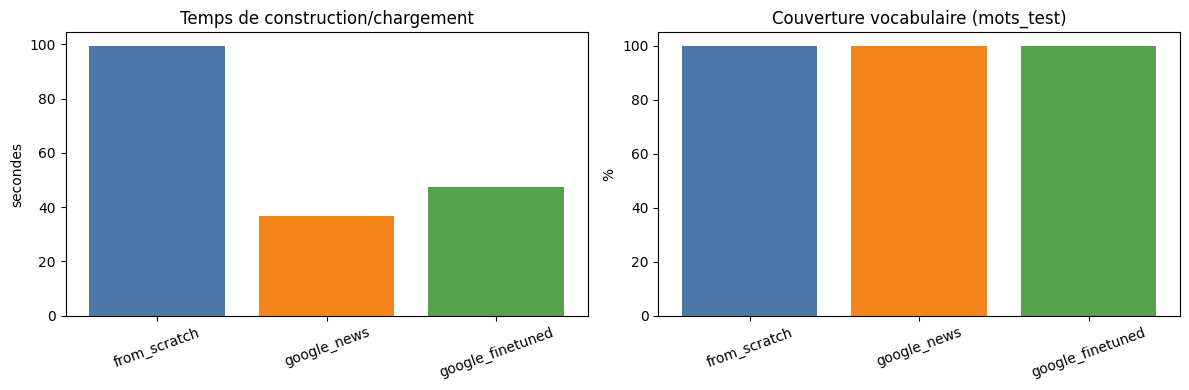

Tableau des similarités (0 si mot absent):
                 paire  from_scratch  google_news  google_finetuned
     quantum-computing         0.208        0.330             0.317
        neural-network         0.585        0.246             0.625
      machine-learning         0.409        0.058             0.435
         deep-learning         0.458        0.070             0.457
algorithm-optimization         0.384        0.418             0.458
          data-science         0.235        0.158             0.268


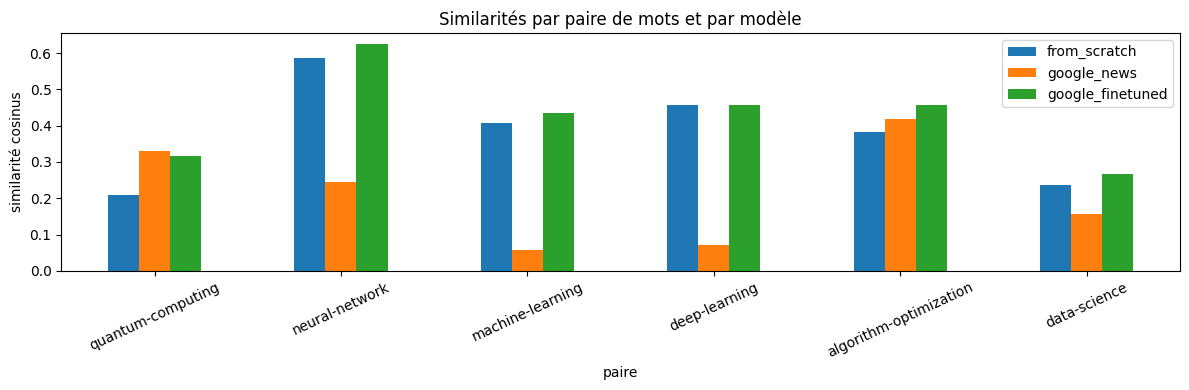

In [82]:
# 3.5 bis) Schémas et graphiques de stats Word2Vec
stats_w2v = pd.DataFrame({
    "modele": ["from_scratch", "google_news", "google_finetuned"],
    "temps_sec": [temps_scratch, temps_google, temps_finetune],
    "couverture_pct": [
        100 * cov_s_num / cov_s_den,
        100 * cov_g_num / cov_g_den,
        100 * cov_f_num / cov_f_den,
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(stats_w2v["modele"], stats_w2v["temps_sec"], color=["#4c78a8", "#f58518", "#54a24b"])
axes[0].set_title("Temps de construction/chargement")
axes[0].set_ylabel("secondes")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(stats_w2v["modele"], stats_w2v["couverture_pct"], color=["#4c78a8", "#f58518", "#54a24b"])
axes[1].set_title("Couverture vocabulaire (mots_test)")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

sim_rows = []
for mot_a, mot_b in paires_test:
    sim_rows.append({
        "paire": f"{mot_a}-{mot_b}",
        "from_scratch": sim_scratch_pair(mot_a, mot_b),
        "google_news": sim_google_pair(mot_a, mot_b),
        "google_finetuned": sim_finetuned_pair(mot_a, mot_b),
    })

df_sim = pd.DataFrame(sim_rows).fillna(0.0)
print("Tableau des similarités (0 si mot absent):")
print(df_sim.round(3).to_string(index=False))

ax = df_sim.set_index("paire").plot(kind="bar", figsize=(12, 4))
ax.set_title("Similarités par paire de mots et par modèle")
ax.set_ylabel("similarité cosinus")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 3.6 Classification Word2Vec simplifiée

Version volontairement simple :
- on garde uniquement les 20 labels les plus fréquents,
- mêmes features TF-IDF pondérées pour les 3 variantes Word2Vec,
- même classifieur OneVsRest + LogisticRegression,
- seuil optimisé par grid search sur validation (objectif F1 micro),
- évaluation finale sur test avec la meilleure valeur de seuil.

### Lire les métriques simplement

- `accuracy_exacte` : match exact de tous les labels d'un document.
- `f1_micro` : métrique principale ici (compromis précision/rappel global).
- `f1_macro` : utile pour voir le comportement sur les classes rares.

Objectif de cette version : garder un pipeline clair et facilement interprétable.

In [ ]:
# 1) Préparer le dataset (top-20 labels) + embeddings documents pondérés TF-IDF
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

df_ml = df.copy()

def normaliser_labels(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            return val if isinstance(val, list) else []
        except Exception:
            return []
    return []

# 1.1 Construire explicitement les 20 labels les plus représentés
df_ml["labels_ml_bruts"] = df_ml[colonne_categories].apply(normaliser_labels)
labels_plats = [lab for labs in df_ml["labels_ml_bruts"] for lab in labs]
top20_labels = [lab for lab, _ in Counter(labels_plats).most_common(20)]
top20_set = set(top20_labels)

df_ml["labels_ml"] = df_ml["labels_ml_bruts"].apply(lambda labs: [lab for lab in labs if lab in top20_set])
df_ml = df_ml[df_ml["labels_ml"].apply(len) > 0].reset_index(drop=True)

# 1.2 Texte d'entrée (summary uniquement)
df_ml["texte_modele"] = df_ml["summaries"].fillna("").astype(str).apply(preprocess_texte)

tokens_docs = [txt.split() for txt in df_ml["texte_modele"].tolist()]
mlb = MultiLabelBinarizer(classes=top20_labels)
Y = mlb.fit_transform(df_ml["labels_ml"])

idx_all = np.arange(len(df_ml))
idx_train_full, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42, shuffle=True)
idx_train, idx_val = train_test_split(idx_train_full, test_size=0.2, random_state=42, shuffle=True)
Y_train, Y_val, Y_test = Y[idx_train], Y[idx_val], Y[idx_test]
texts_train = df_ml.iloc[idx_train]["texte_modele"].tolist()

# 1.3 Pondération TF-IDF pour construire les vecteurs document
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None, min_df=3, max_df=0.8
)
tfidf_vectorizer.fit(texts_train)
idf_map = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))

dim_emb = w2v_scratch.vector_size

def mot_valide(modele, token):
    if hasattr(modele, "wv"):
        return token if token in modele.wv.key_to_index else None
    return mot_connu(modele, token)

def vecteur_token(modele, token):
    return modele.wv[token] if hasattr(modele, "wv") else modele[token]

def doc_embedding_pondere(tokens, modele):
    vecs = []
    poids = []
    for token in tokens:
        mot = mot_valide(modele, token)
        if mot is None:
            continue
        vecs.append(vecteur_token(modele, mot))
        poids.append(idf_map.get(token, 1.0))
    if not vecs:
        return np.zeros(dim_emb, dtype=np.float32)
    return np.average(
        np.asarray(vecs, dtype=np.float32),
        axis=0,
        weights=np.asarray(poids, dtype=np.float32)
    ).astype(np.float32)

X_scratch = np.vstack([doc_embedding_pondere(toks, w2v_scratch) for toks in tokens_docs])
X_google = np.vstack([doc_embedding_pondere(toks, w2v_google) for toks in tokens_docs])
X_finetuned = np.vstack([doc_embedding_pondere(toks, w2v_finetuned) for toks in tokens_docs])

X_scratch_train, X_scratch_val, X_scratch_test = X_scratch[idx_train], X_scratch[idx_val], X_scratch[idx_test]
X_google_train, X_google_val, X_google_test = X_google[idx_train], X_google[idx_val], X_google[idx_test]
X_finetuned_train, X_finetuned_val, X_finetuned_test = X_finetuned[idx_train], X_finetuned[idx_val], X_finetuned[idx_test]

print(f"Nombre de documents utilisés: {len(df_ml)}")
print(f"Nombre de classes conservées: {len(mlb.classes_)}")
print("Top-20 labels:", list(mlb.classes_))
print("- X_scratch:", X_scratch.shape)
print("- X_google:", X_google.shape)
print("- X_finetuned:", X_finetuned.shape)
print("- Split train/val/test:", len(idx_train), "/", len(idx_val), "/", len(idx_test))

Nombre de documents utilisés: 38985
Nombre de classes conservées: 20
Top-20 labels: ['cs.CV', 'cs.LG', 'stat.ML', 'cs.AI', 'eess.IV', 'cs.RO', 'cs.CL', 'cs.NE', 'cs.CR', 'math.OC', 'eess.SP', 'cs.GR', 'cs.SI', 'cs.SY', 'cs.MM', 'cs.IR', 'cs.MA', 'eess.SY', 'cs.HC', 'cs.IT']
- X_scratch: (38985, 300)
- X_google: (38985, 300)
- X_finetuned: (38985, 300)
- Split train/val/test: 24950 / 6238 / 7797


In [96]:
# 2) Entraîner les 3 modèles + grid search de seuil (objectif F1 micro validation)
def entrainer_evaluer_modele(nom_modele, X_train, X_val, X_test, Y_train, Y_val, Y_test):
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs", class_weight="balanced")
    )

    t0 = time.time()
    clf.fit(X_train, Y_train)
    temps_train = time.time() - t0

    proba_val = clf.predict_proba(X_val)
    proba_test = clf.predict_proba(X_test)

    grille_seuils = np.linspace(0.10, 0.90, 33)
    meilleur_seuil = 0.5
    meilleur_f1_val = -1.0

    for seuil in grille_seuils:
        y_val_pred = (proba_val >= seuil).astype(int)
        score = f1_score(Y_val, y_val_pred, average="micro", zero_division=0)
        if score > meilleur_f1_val:
            meilleur_f1_val = score
            meilleur_seuil = float(seuil)

    seuils = np.full(Y.shape[1], meilleur_seuil, dtype=np.float32)
    Y_pred = (proba_test >= seuils[None, :]).astype(int)

    metrics = {
        "modele": nom_modele,
        "f1_val_micro": meilleur_f1_val,
        "seuil_optimal": meilleur_seuil,
        "accuracy_exacte": accuracy_score(Y_test, Y_pred),
        "precision_micro": precision_score(Y_test, Y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(Y_test, Y_pred, average="micro", zero_division=0),
        "f1_micro": f1_score(Y_test, Y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(Y_test, Y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(Y_test, Y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(Y_test, Y_pred, average="macro", zero_division=0),
        "temps_entrainement_sec": temps_train,
        "seuil_moyen": float(np.mean(seuils)),
        "seuil_min": float(np.min(seuils)),
        "seuil_max": float(np.max(seuils)),
    }

    try:
        metrics["roc_auc_micro"] = roc_auc_score(Y_test, proba_test, average="micro")
    except Exception:
        metrics["roc_auc_micro"] = np.nan

    report_dict = classification_report(
        Y_test, Y_pred, target_names=list(mlb.classes_), output_dict=True, zero_division=0
    )
    df_report = pd.DataFrame(report_dict).transpose()

    return clf, seuils, Y_pred, metrics, df_report

clf_scratch, seuils_scratch, Y_pred_scratch, met_scratch, rep_scratch = entrainer_evaluer_modele(
    "W2V_from_scratch", X_scratch_train, X_scratch_val, X_scratch_test, Y_train, Y_val, Y_test
)
clf_google, seuils_google, Y_pred_google, met_google, rep_google = entrainer_evaluer_modele(
    "W2V_google_news", X_google_train, X_google_val, X_google_test, Y_train, Y_val, Y_test
)
clf_finetuned, seuils_finetuned, Y_pred_finetuned, met_finetuned, rep_finetuned = entrainer_evaluer_modele(
    "W2V_google_finetuned", X_finetuned_train, X_finetuned_val, X_finetuned_test, Y_train, Y_val, Y_test
)

print("Entraînement terminé (pipeline simple + seuil optimisé par grid search F1).")
print(f"W2V_from_scratch  | F1_val_micro={met_scratch['f1_val_micro']:.4f} | seuil={met_scratch['seuil_optimal']:.3f}")
print(f"W2V_google_news   | F1_val_micro={met_google['f1_val_micro']:.4f} | seuil={met_google['seuil_optimal']:.3f}")
print(f"W2V_google_finetuned | F1_val_micro={met_finetuned['f1_val_micro']:.4f} | seuil={met_finetuned['seuil_optimal']:.3f}")

Entraînement terminé (pipeline simple + seuil optimisé par grid search F1).
W2V_from_scratch  | F1_val_micro=0.6151 | seuil=0.750
W2V_google_news   | F1_val_micro=0.5576 | seuil=0.700
W2V_google_finetuned | F1_val_micro=0.6123 | seuil=0.750


In [99]:
# 3) Comparaison globale des performances
df_resultats = pd.DataFrame([met_scratch, met_google, met_finetuned])
colonnes_ordre = [
    "modele",
    "accuracy_exacte",
    "precision_micro", "recall_micro", "f1_micro",
    "precision_macro", "recall_macro", "f1_macro",
    "roc_auc_micro",
    "seuil_moyen",
    "temps_entrainement_sec",
]
df_resultats = df_resultats[colonnes_ordre].sort_values(by="f1_micro", ascending=False).reset_index(drop=True)

df_affiche = df_resultats.round({
    "accuracy_exacte": 4,
    "precision_micro": 4,
    "recall_micro": 4,
    "f1_micro": 4,
    "precision_macro": 4,
    "recall_macro": 4,
    "f1_macro": 4,
    "roc_auc_micro": 4,
    "seuil_moyen": 3,
    "temps_entrainement_sec": 2
})
print("Résumé global:")
print(df_affiche.to_string(index=False))

print("Classement (meilleur F1 micro test en tête) :")
for i, row in df_resultats.iterrows():
    print(
        f"{i+1}. {row['modele']} | F1_micro={row['f1_micro']:.4f} "
        f"| Precision_micro={row['precision_micro']:.4f} | Recall_micro={row['recall_micro']:.4f}"
    )

Résumé global:
              modele  accuracy_exacte  precision_micro  recall_micro  f1_micro  precision_macro  recall_macro  f1_macro  roc_auc_micro  seuil_moyen  temps_entrainement_sec
W2V_google_finetuned           0.2328           0.5723        0.6730    0.6186           0.2914        0.6166    0.3401         0.9339         0.75                    5.25
    W2V_from_scratch           0.2360           0.5698        0.6728    0.6170           0.2918        0.6201    0.3410         0.9339         0.75                    4.49
     W2V_google_news           0.1751           0.4997        0.6252    0.5555           0.2536        0.5656    0.2915         0.9059         0.70                    3.44
Classement (meilleur F1 micro test en tête) :
1. W2V_google_finetuned | F1_micro=0.6186 | Precision_micro=0.5723 | Recall_micro=0.6730
2. W2V_from_scratch | F1_micro=0.6170 | Precision_micro=0.5698 | Recall_micro=0.6728
3. W2V_google_news | F1_micro=0.5555 | Precision_micro=0.4997 | Recall_micro=

### Formules détaillées: micro vs macro

Pour une classe $k$, on note:
- $TP_k$: vrais positifs
- $FP_k$: faux positifs
- $FN_k$: faux négatifs

Précision par classe:
$$P_k = \frac{TP_k}{TP_k + FP_k}$$

Rappel par classe:
$$R_k = \frac{TP_k}{TP_k + FN_k}$$

F1-score par classe:
$$F1_k = \frac{2 P_k R_k}{P_k + R_k}$$

Agrégration micro (on somme d'abord tous les TP/FP/FN sur toutes les classes):
$$P_{micro} = \frac{\sum_k TP_k}{\sum_k (TP_k + FP_k)}$$
$$R_{micro} = \frac{\sum_k TP_k}{\sum_k (TP_k + FN_k)}$$
$$F1_{micro} = \frac{2 P_{micro} R_{micro}}{P_{micro} + R_{micro}}$$

Agrégration macro (on calcule chaque classe puis moyenne simple):
$$P_{macro} = \frac{1}{K}\sum_k P_k$$
$$R_{macro} = \frac{1}{K}\sum_k R_k$$
$$F1_{macro} = \frac{1}{K}\sum_k F1_k$$

Interprétation rapide:
- `micro` favorise les classes fréquentes (vision globale).
- `macro` donne le même poids à chaque classe (sensible aux classes rares).

In [104]:
# affiche le seuil optimal pour le modéle finetuned 
print(f"Seuil optimal pour W2V_google_finetuned : {met_finetuned['seuil_optimal']:.3f} (F1 micro val: {met_finetuned['f1_val_micro']:.4f})")

Seuil optimal pour W2V_google_finetuned : 0.750 (F1 micro val: 0.6123)


In [100]:
# 4) Détail par classe pour le meilleur modèle (sans accuracy/support)
meilleur_indice = df_resultats.index[0]
meilleur_modele = df_resultats.loc[meilleur_indice, "modele"]
report_meilleur = {
    "W2V_from_scratch": rep_scratch,
    "W2V_google_news": rep_google,
    "W2V_google_finetuned": rep_finetuned,
}[meilleur_modele]

def extraire_par_classe(y_true, y_pred):
    lignes = []
    for i, classe in enumerate(mlb.classes_):
        vrai = y_true[:, i]
        pred = y_pred[:, i]
        lignes.append({
            "classe": classe,
            "precision": precision_score(vrai, pred, zero_division=0),
            "recall": recall_score(vrai, pred, zero_division=0),
            "f1_score": f1_score(vrai, pred, zero_division=0),
        })
    return pd.DataFrame(lignes)

y_pred_meilleur = {
    "W2V_from_scratch": Y_pred_scratch,
    "W2V_google_news": Y_pred_google,
    "W2V_google_finetuned": Y_pred_finetuned,
}[meilleur_modele]

detail_meilleur = extraire_par_classe(Y_test, y_pred_meilleur)

print(f"Meilleur modèle retenu: {meilleur_modele}")
print(detail_meilleur.sort_values(by="f1_score", ascending=False).round(4).to_string(index=False))

Meilleur modèle retenu: W2V_google_finetuned
 classe  precision  recall  f1_score
  cs.CV     0.9790  0.8284    0.8974
  cs.LG     0.9496  0.7129    0.8144
stat.ML     0.7128  0.5464    0.6186
  cs.CR     0.3525  0.8455    0.4976
  cs.CL     0.3198  0.7435    0.4472
  cs.MA     0.2871  0.8219    0.4255
  cs.RO     0.3058  0.6763    0.4212
  cs.AI     0.5338  0.3328    0.4100
  cs.SI     0.1746  0.6705    0.2770
math.OC     0.1561  0.7708    0.2596
eess.IV     0.1543  0.3459    0.2135
eess.SP     0.1239  0.6082    0.2059
  cs.IR     0.1206  0.5942    0.2005
  cs.GR     0.1166  0.6706    0.1986
eess.SY     0.1175  0.6324    0.1982
  cs.SY     0.1147  0.6024    0.1927
  cs.NE     0.1090  0.3977    0.1711
  cs.HC     0.0747  0.5306    0.1310
  cs.MM     0.0660  0.5513    0.1178
  cs.IT     0.0591  0.4490    0.1045


### Visualisation OneVsRest et performances

> On visualise ici les performances OneVsRest du meilleur modèle sur le test set, classe par classe.

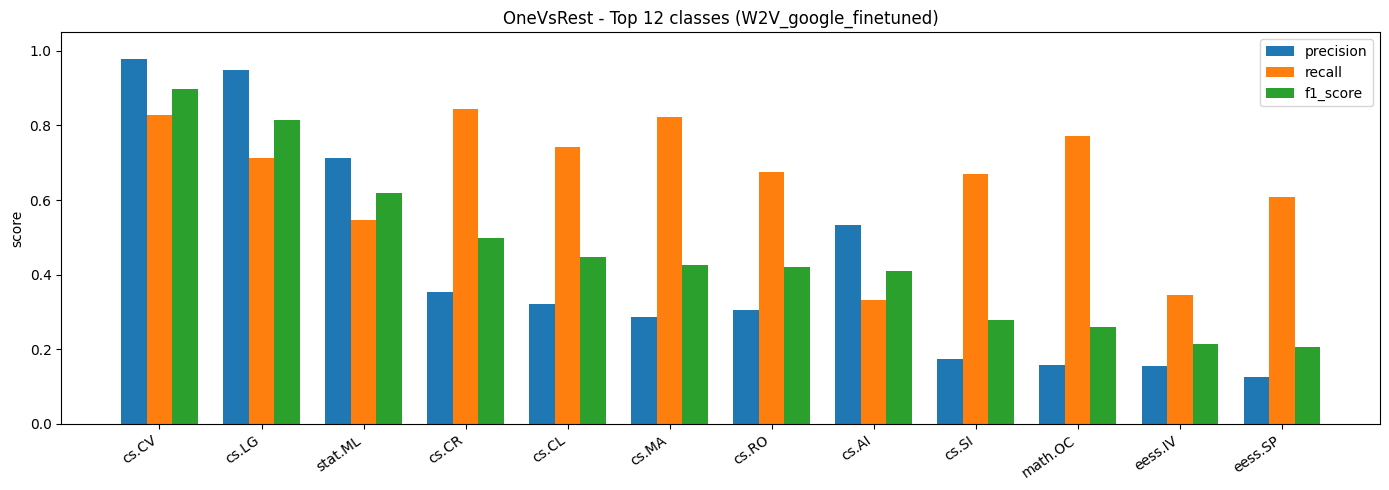

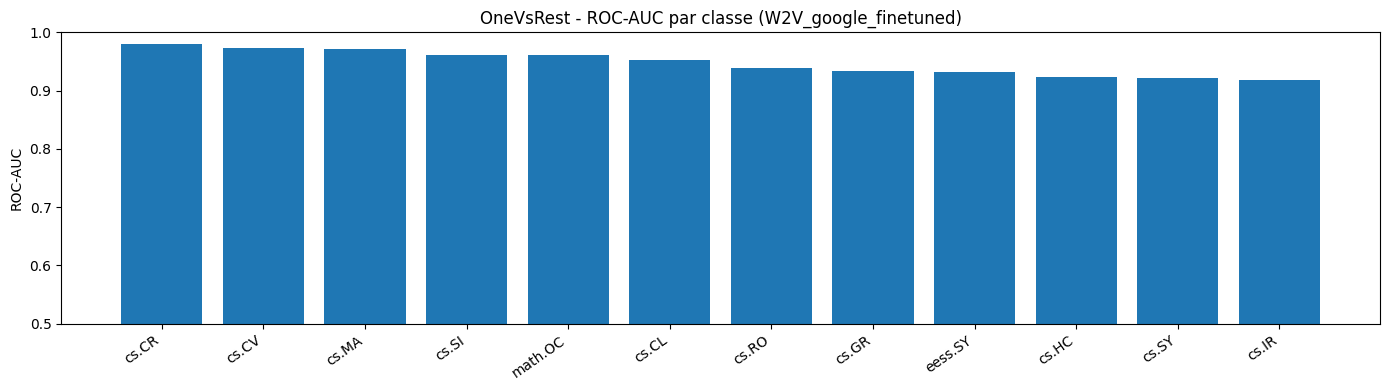

Résumé global du meilleur modèle:
              modele  precision_micro  recall_micro  f1_micro  precision_macro  recall_macro  f1_macro  seuil_moyen  roc_auc_micro
W2V_google_finetuned           0.5723         0.673    0.6186           0.2914        0.6166    0.3401         0.75         0.9339

Top classes (F1):
 classe  precision  recall  f1_score  support
  cs.CV     0.9790  0.8284    0.8974     4492
  cs.LG     0.9496  0.7129    0.8144     4388
stat.ML     0.7128  0.5464    0.6186     2434
  cs.CR     0.3525  0.8455    0.4976      123
  cs.CL     0.3198  0.7435    0.4472      191
  cs.MA     0.2871  0.8219    0.4255       73
  cs.RO     0.3058  0.6763    0.4212      312
  cs.AI     0.5338  0.3328    0.4100     1211
  cs.SI     0.1746  0.6705    0.2770       88
math.OC     0.1561  0.7708    0.2596       96
eess.IV     0.1543  0.3459    0.2135      344
eess.SP     0.1239  0.6082    0.2059       97


In [103]:
# 4 bis) Plots OneVsRest + performances détaillées
modele_to_assets = {
    "W2V_from_scratch": (clf_scratch, X_scratch_test, Y_pred_scratch),
    "W2V_google_news": (clf_google, X_google_test, Y_pred_google),
    "W2V_google_finetuned": (clf_finetuned, X_finetuned_test, Y_pred_finetuned),
}

clf_best, X_best_test, Y_pred_best = modele_to_assets[meilleur_modele]
proba_best = clf_best.predict_proba(X_best_test)

# Perf par classe (OneVsRest)
lignes = []
for i, classe in enumerate(mlb.classes_):
    y_true_i = Y_test[:, i]
    y_pred_i = Y_pred_best[:, i]
    lignes.append({
        "classe": classe,
        "precision": precision_score(y_true_i, y_pred_i, zero_division=0),
        "recall": recall_score(y_true_i, y_pred_i, zero_division=0),
        "f1_score": f1_score(y_true_i, y_pred_i, zero_division=0),
        "support": int(y_true_i.sum()),
    })

df_ovr_perf = pd.DataFrame(lignes).sort_values("f1_score", ascending=False).reset_index(drop=True)

# ROC-AUC par classe
auc_lignes = []
for i, classe in enumerate(mlb.classes_):
    y_true_i = Y_test[:, i]
    if len(np.unique(y_true_i)) < 2:
        auc_i = np.nan
    else:
        auc_i = roc_auc_score(y_true_i, proba_best[:, i])
    auc_lignes.append({"classe": classe, "roc_auc": auc_i})

df_auc = pd.DataFrame(auc_lignes).sort_values("roc_auc", ascending=False).reset_index(drop=True)

# Plot 1 : Precision/Recall/F1 par classe (top 12 F1)
top_n = 12
df_plot = df_ovr_perf.head(top_n).copy()
x = np.arange(len(df_plot))
w = 0.25

plt.figure(figsize=(14, 5))
plt.bar(x - w, df_plot["precision"], width=w, label="precision")
plt.bar(x, df_plot["recall"], width=w, label="recall")
plt.bar(x + w, df_plot["f1_score"], width=w, label="f1_score")
plt.xticks(x, df_plot["classe"], rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.title(f"OneVsRest - Top {top_n} classes ({meilleur_modele})")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 : ROC-AUC par classe
df_auc_plot = df_auc.dropna().head(top_n)
plt.figure(figsize=(14, 4))
plt.bar(df_auc_plot["classe"], df_auc_plot["roc_auc"])
plt.xticks(rotation=35, ha="right")
plt.ylim(0.5, 1.0)
plt.title(f"OneVsRest - ROC-AUC par classe ({meilleur_modele})")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

# Résumé perf du meilleur modèle (colonnes robustes selon état df_resultats)
colonnes_resume = [
    "modele", "precision_micro", "recall_micro", "f1_micro",
    "precision_macro", "recall_macro", "f1_macro",
    "seuil_optimal", "f1_val_micro",
    "seuil_moyen", "roc_auc_micro"
]
colonnes_disponibles = [c for c in colonnes_resume if c in df_resultats.columns]
resume = df_resultats.loc[df_resultats["modele"] == meilleur_modele, colonnes_disponibles].copy()

print("Résumé global du meilleur modèle:")
print(resume.round(4).to_string(index=False))

print("\nTop classes (F1):")
print(df_ovr_perf[["classe", "precision", "recall", "f1_score", "support"]].head(12).round(4).to_string(index=False))

In [101]:
# 5) Test manuel du meilleur modèle : prédictions vs labels réels sur des exemples du test set
modele_to_assets = {
    "W2V_from_scratch": (clf_scratch, X_scratch_test, seuils_scratch),
    "W2V_google_news": (clf_google, X_google_test, seuils_google),
    "W2V_google_finetuned": (clf_finetuned, X_finetuned_test, seuils_finetuned),
}

clf_best, X_best_test, seuils_best = modele_to_assets[meilleur_modele]
proba_best_test = clf_best.predict_proba(X_best_test)
pred_best_test = (proba_best_test >= seuils_best[None, :]).astype(int)

def decode_labels(binary_vec, classes):
    return [classes[i] for i, v in enumerate(binary_vec) if v == 1]

def comparer_exemple(local_idx):
    global_idx = idx_test[local_idx]
    titre = df_ml.iloc[global_idx]["titles"]
    texte = df_ml.iloc[global_idx]["texte_modele"]
    vrais = decode_labels(Y_test[local_idx], mlb.classes_)
    predits = decode_labels(pred_best_test[local_idx], mlb.classes_)
    correct_exact = set(vrais) == set(predits)

    print("=" * 110)
    print(f"Exemple test local #{local_idx} | index global df_ml={global_idx}")
    print(f"Titre: {titre}")
    print(f"Texte (début): {texte[:220]}...")
    print(f"Labels réels   ({len(vrais)}): {vrais}")
    print(f"Labels prédits ({len(predits)}): {predits}")
    print(f"Match exact: {correct_exact}")

indices_fixes = [0, 5, 25, 120]
rng = np.random.default_rng(42)
indices_random = rng.choice(len(Y_test), size=3, replace=False).tolist()
indices_a_tester = []
for idx_local in indices_fixes + indices_random:
    if 0 <= idx_local < len(Y_test) and idx_local not in indices_a_tester:
        indices_a_tester.append(idx_local)

print(f"Modèle testé manuellement: {meilleur_modele}")
print(f"Nombre d'exemples inspectés: {len(indices_a_tester)}")
for idx_local in indices_a_tester:
    comparer_exemple(idx_local)

Modèle testé manuellement: W2V_google_finetuned
Nombre d'exemples inspectés: 7
Exemple test local #0 | index global df_ml=22014
Titre: A Three-stage Approach for Segmenting Degraded Color Images: Smoothing, Lifting and Thresholding (SLaT)
Texte (début): threestage approach segmenting degraded color image smoothing lifting thresholding slat paper propose slat smoothing lifting thresholding method three stage multiphase segmentation color image corrupted different degrada...
Labels réels   (1): ['cs.CV']
Labels prédits (1): ['cs.CV']
Match exact: True
Exemple test local #5 | index global df_ml=1616
Titre: Adversarial Stacked Auto-Encoders for Fair Representation Learning
Texte (début): adversarial stacked autoencoders fair representation learning training machine learning model accuracy final goal may promote prejudice discriminatory behavior embedded data one solution learn latent representation fulfi...
Labels réels   (2): ['cs.LG', 'cs.AI']
Labels prédits (3): ['cs.LG', 'stat.ML', 'cs

### Entrainement doc2Vec

Documentation de l'api : https://radimrehurek.com/gensim/models/doc2vec.html

hypothèse : on traite les summaries ici comme des documents et la finalité ce sera donc de comparer directement l'approche avec du word2Vec , Glove et les sentenceTransformers ...

In [88]:
from gensim.models.doc2vec import Doc2Vec , TaggedDocument
from gensim.test.utils import get_tmpfile #pour poursuivre entrainement sur modèle loaded  si ça se finit pas ??? 

import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO) #pour epochs dans training



documents_tagges = [TaggedDocument(doc.split(),[f"doc_{i}"]) for i,doc in enumerate(PHRASES_DOCUMENT_NETTOYEES)]

doc2vec_conf = {"vector_size":300,"window":5,"min_count":5,"workers":16,"dm":0,"epochs":50} # 1 moins bon pour les mots rares test avec dm = 0  équivalent skip gram

doc2vec_modele = Doc2Vec(**doc2vec_conf)#pv-dm en mettant  = 1

doc2vec_modele.build_vocab(documents_tagges) #prépare modele pour entrainement , word frequency ...
print(f"vocabulaire : {len(doc2vec_modele.wv)} mots")

# doc2vec_modele.train(documents_tagges, total_examples=doc2vec_modele.corpus_count, epochs=doc2vec_modele.epochs)


2026-04-17 00:19:40,466 : INFO : Doc2Vec lifecycle event {'params': 'Doc2Vec<dbow,d300,n5,mc5,s0.001,t16>', 'datetime': '2026-04-17T00:19:40.466116', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-17 00:19:40,503 : INFO : collecting all words and their counts
2026-04-17 00:19:40,503 : INFO : PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
2026-04-17 00:19:40,660 : INFO : PROGRESS: at example #10000, processed 1098862 words (7047547 words/s), 35722 word types, 10000 tags
2026-04-17 00:19:40,827 : INFO : PROGRESS: at example #20000, processed 2191175 words (6591420 words/s), 57348 word types, 20000 tags
2026-04-17 00:19:40,977 : INFO : PROGRESS: at example #30000, processed 3237262 words (7018193 words/s), 74517 word types, 30000 tags
2026-04-17 00:19:41,245 : INFO : collected 89294 word types and 38985 unique tags from a corp

vocabulaire : 20044 mots


In [89]:

documents_embeddings = [doc2vec_modele.dv[f'doc_{i}'] for i in range(len(PHRASES_DOCUMENT_NETTOYEES))]
X_doc2vec = np.array(documents_embeddings)

print(f"Shape Doc2Vec: {X_doc2vec.shape}")

Shape Doc2Vec: (38985, 300)


### chargement du modèle ou persistence
on persiste embeddings ici 


In [90]:
np.save(f"models/embeddings_doc2vec_{doc2vec_modele.vector_size}_sans_doublons_{doc2vec_modele.epochs}_epochs_{doc2vec_modele.sg}_dmcbow.npy", X_doc2vec)
# X_doc2vec = np.load(f"models/embeddings_doc2vec_{doc2vec_modele.vector_size}.npy")



FileNotFoundError: [Errno 2] No such file or directory: 'models/embeddings_doc2vec_300_sans_doublons_50_epochs_1_dmcbow.npy'

### test similarités nouveau modele

In [ ]:

def inference_nouveau_document(doc: str , top_n = 10):
    tokens = preprocess_texte(doc).split()
    nouveau_vec = doc2vec_modele.infer_vector(tokens)
    # print("nouveau vec : ",nouveau_vec)
    similaires_inferes = doc2vec_modele.dv.most_similar([nouveau_vec], topn=top_n)
    print("Documents similaires au nouveau texte :")
    for doc_id, sim in similaires_inferes:
        print(f"{doc_id}: {sim:.3f}")
        document_contenu_categories = df.iloc[int(doc_id.split("_")[1]),2]
        document_contenu_title = df.iloc[int(doc_id.split("_")[1]),1]
        print(f"contenu du document associé : {document_contenu_categories}, \n {document_contenu_title}")
inference_nouveau_document("physics quantum")

Documents similaires au nouveau texte :
doc_25831: 0.233
contenu du document associé : ['cs.CV', 'cs.AI'], 
 Purpose: Lesion segmentation in medical imaging is key to evaluating
treatment response. We have recently shown that reinforcement learning can be
applied to radiological images for lesion localization. Furthermore, we
demonstrated that reinforcement learning addresses important limitations of
supervised deep learning; namely, it can eliminate the requirement for large
amounts of annotated training data and can provide valuable intuition lacking
in supervised approaches. However, we did not address the fundamental task of
lesion/structure-of-interest segmentation. Here we introduce a method combining
unsupervised deep learning clustering with reinforcement learning to segment
brain lesions on MRI.
  Materials and Methods: We initially clustered images using unsupervised deep
learning clustering to generate candidate lesion masks for each MRI image. The
user then selected the bes

In [ ]:
from collections import Counter
all_words = [word for doc in PHRASES_DOCUMENT_NETTOYEES for word in doc.split()]
word_freq = Counter(all_words)
print(word_freq.get('physic', 0), word_freq.get('network', 0))

323 41657


### remarque intéressante : 

bias énorme dans les données 323 41657 pour physic vs neural networks : 

post entrainement : inference_nouveau_document("physics quantum")

Documents similaires au nouveau texte :

doc_16717: 0.843
contenu du document associé : ['cs.CV', 'cs.CR'], 
 deep neural network achieved remarkable success computer vision natural language processing audio task

doc_33994: 0.731
contenu du document associé : ['cs.CV'], 
 participated task lesion segmentation paper describes algorithm final result validation set isic challenge skin lesion analysis towards melanoma detection

doc_27182: 0.721
contenu du document associé : ['cs.LG', 'stat.ML'], 
 paper withdrawn

doc_19332: 0.644
contenu du document associé : ['cs.LG', 'stat.ML'], 
 graph neural network gnns effective machine learning model various graph learning problem despite empirical success theoretical limitation gnns revealed recently consequently many gnn model proposed overcome limitation survey provide comprehensive overview expressive power gnns provably powerful varian


### Corriger le biais 

Les 40 identifiants CS sont :
cs.AI, cs.AR, cs.CC, cs.CE, cs.CG, cs.CL, cs.CR, cs.CV, cs.CY, cs.DB, cs.DC, cs.DL, cs.DM, cs.DS, cs.ET, cs.FL, cs.GL, cs.GR, cs.GT, cs.HC, cs.IR, cs.IT, cs.LG, cs.LO, cs.MA, cs.MM, cs.MS, cs.NA, cs.NE, cs.NI, cs.OH, cs.OS, cs.PF, cs.PL, cs.RO, cs.SC, cs.SD, cs.SE, cs.SI, cs.SY.
En très bref : cs.AI = IA générale, cs.CV = vision/pattern recognition, cs.CL = NLP, cs.LG = machine learning, cs.RO = robotique, cs.IR = recherche d’info, cs.CR = crypto/sécurité, cs.SE = génie logiciel, cs.DB = bases de données, cs.NI = réseaux, cs.DS = structures de données/algos, cs.LO = logique, cs.GT = game theory côté informatique, etc. cs.NA et cs.SY sont bien présents dans la taxonomie, mais comme alias seulement.


ON peut filtrer directement sur eux

## Modèle embedding document 2 :  On essaie de faire de la classification à partir des 20 catégories filtrées


on essaie de tester un modèle d'embeddings de scibert // allmini lm v6 si on a le temps dans un second temps 

In [ ]:
from transformers import AutoTokenizer, AutoModel

nom_modele = "allenai/scibert_scivocab_uncased" #vocab meilleur et baseb https://github.com/allenai/scibert , modeles dispo sur huggings face
tokenizer = AutoTokenizer.from_pretrained(nom_modele)
modele_scibert = AutoModel.from_pretrained(nom_modele,use_safetensors = True) #forcer chargement poids di modele depuis safetensoers plus sécurisé que le pickle 

In [ ]:
import torch

text = "This paper proposes a new method for image classification."

inputs = tokenizer(
    text,
    return_tensors="pt", 
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = modele_scibert(**inputs)


print(outputs.last_hidden_state.shape)

torch.Size([1, 12, 768])


In [ ]:
from torch.utils.data import DataLoader, Dataset
import torch

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        inputs = self.tokenizer(
            text,
            truncation=True,          
            padding='max_length',     
            max_length=self.max_length,
            return_tensors="pt"       
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}

texts = PHRASES_DOCUMENT_NETTOYEES  # Tes textes nettoyés
batch_size = 32  
dataset = TextDataset(texts, tokenizer, max_length=128)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

embeddings = []
modele_scibert.eval()
with torch.no_grad():
    for batch in dataloader:
        outputs = modele_scibert(**batch)
        masque_attention = batch['attention_mask'] 
        masque_cache = outputs.last_hidden_state * masque_attention.unsqueeze(-1) #(batch, seq_length, hidden_size) * ((batch, seq_length, 1))
        sentence_emb = masque_cache.sum(dim=1) / masque_attention.sum(dim=1)
        embeddings.append(sentence_emb)

X_scibert = torch.cat(embeddings, dim=0).numpy()
print(X_scibert.shape)